In [61]:
import numpy as np
import os
import random
import cv2
from PIL import Image, ImageDraw, ImageFont
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [64]:
# ==========================================
# 2. PYTHON SCRIPT
# ==========================================

# --- CONFIGURATION ---
IMAGE_SIZE = 64
SAMPLES_PER_CHAR = 1000
SAMPLES_PER_CONFUSED = 2000
FILENAME = "dataset_aligned.npz"
OUTPUT_PATH = FILENAME
PADDING = 10          # MATCHES YOUR OPENCV SCRIPT

In [65]:
# =============================================================================
# Konfiguration
# =============================================================================

# Zeichensatz
chars_lower = "abcdefghijklmnopqrstuvwxyz"
chars_upper = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
numbers = "0123456789"
german_specials = "äöüÄÖÜß"
punctuation = ".,;:!?()+-'@"

ALL_CHARS = list(chars_lower + chars_upper + numbers + german_specials + punctuation)
CONFUSED_PAIRS = ['o', '0', 'O', 'I', 'l', '1', ',', '.', '(', ')', "'"]

# =============================================================================
# Funktionen
# =============================================================================

FONT_DIR = os.path.join(os.getcwd(), "Fonts")

def get_fonts():
    if not os.path.exists(FONT_DIR):
        print(f"FEHLER: Font-Ordner nicht gefunden: {FONT_DIR}")
        return []
    return [
        os.path.join(FONT_DIR, f)
        for f in os.listdir(FONT_DIR)
        if f.lower().endswith(".ttf")
    ]

def augment_image(pil_img):
    """Wendet Rotation und Blur auf ein PIL-Bild (Mode 'L') an,
    thresholded dann zurück auf binär.
    """
    # 1) Leichte Rotation (±5°)
    if random.random() > 0.4:
        angle = random.uniform(-5, 5)
        pil_img = pil_img.rotate(angle, fillcolor=255)

    # 2) Leichter Gauß-Blur (weicht Kanten auf, wie bei echten Scans)
    if random.random() > 0.5:
        img_np = np.array(pil_img, dtype=np.uint8)
        ksize = 3
        img_np = cv2.GaussianBlur(img_np, (ksize, ksize), 0)
        pil_img = Image.fromarray(img_np)

    # 3) Zurück auf binär thresholden (wie unser Preprocessing)
    img_np = np.array(pil_img, dtype=np.uint8)
    _, img_np = cv2.threshold(img_np, 127, 255, cv2.THRESH_BINARY)

    return img_np

def generate_and_save():

    # 1. Fonts finden
    valid_fonts = get_fonts()
    print(f"Gefundene Fonts: {len(valid_fonts)}")

    if not valid_fonts:
        print(f"FEHLER: Keine .ttf Fonts in '{FONT_DIR}' gefunden!")
        return

    for f in valid_fonts:
        print(f"  - {os.path.basename(f)}")

    # 2. Speicher reservieren
    total_images = len(ALL_CHARS) * SAMPLES_PER_CHAR + len(CONFUSED_PAIRS) * (SAMPLES_PER_CONFUSED - SAMPLES_PER_CHAR)
    print(f"\nGeneriere {total_images} Bilder für {len(ALL_CHARS)} Zeichen...")

    X = np.empty((total_images, IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
    y = np.empty(total_images, dtype=np.int32)

    current_idx = 0
    target_line_height = IMAGE_SIZE - (PADDING * 2)

    # 3. Generierungsschleife
    pbar = tqdm(total=total_images, desc="Fortschritt")

    for char_idx, char in enumerate(ALL_CHARS):
        n_samples = SAMPLES_PER_CONFUSED if char in CONFUSED_PAIRS else SAMPLES_PER_CHAR
        for _ in range(n_samples):
            font_path = random.choice(valid_fonts)

            # Fontgröße mit leichter Variation
            font_size = int(target_line_height * random.uniform(0.90, 1.05))

            # Kleine Positionsverschiebung (simuliert Scan-Ungenauigkeiten)
            offset_x = random.randint(-2, 2)
            offset_y = random.randint(-2, 2)

            try:
                font = ImageFont.truetype(font_path, font_size)
            except:
                continue

            # Bild erstellen (Graustufen, damit Blur funktioniert)
            img = Image.new('L', (IMAGE_SIZE, IMAGE_SIZE), color=255)
            draw = ImageDraw.Draw(img)

            # Horizontal zentrieren
            length = draw.textlength(char, font=font)
            pos_x = (IMAGE_SIZE - length) / 2 + offset_x
            pos_y = PADDING + offset_y

            # Zeichen zeichnen
            draw.text((pos_x, pos_y), char, font=font, fill=0, anchor="la")

            # Augmentierung (Rotation + Blur + Threshold zurück auf binär)
            img_array = augment_image(img)

            # In Array speichern
            X[current_idx] = img_array
            y[current_idx] = char_idx
            current_idx += 1
            pbar.update(1)

    pbar.close()

    # 4. Speichern
    print(f"\nSpeichere nach: {OUTPUT_PATH}")
    np.savez_compressed(OUTPUT_PATH, X=X, y=y, chars=np.array(ALL_CHARS))
    print(f"Fertig! {current_idx} Bilder gespeichert.")
    print(f"Zeichenklassen: {len(ALL_CHARS)}")


if __name__ == "__main__":
    generate_and_save()

Gefundene Fonts: 6
  - ARIAL.TTF
  - CALIBRI.TTF
  - FRAHV.TTF
  - GARA.TTF
  - GEORGIA.TTF
  - TIMES.TTF

Generiere 92000 Bilder für 81 Zeichen...


Fortschritt:   0%|          | 0/92000 [00:00<?, ?it/s]


Speichere nach: dataset_aligned.npz
Fertig! 92000 Bilder gespeichert.
Zeichenklassen: 81


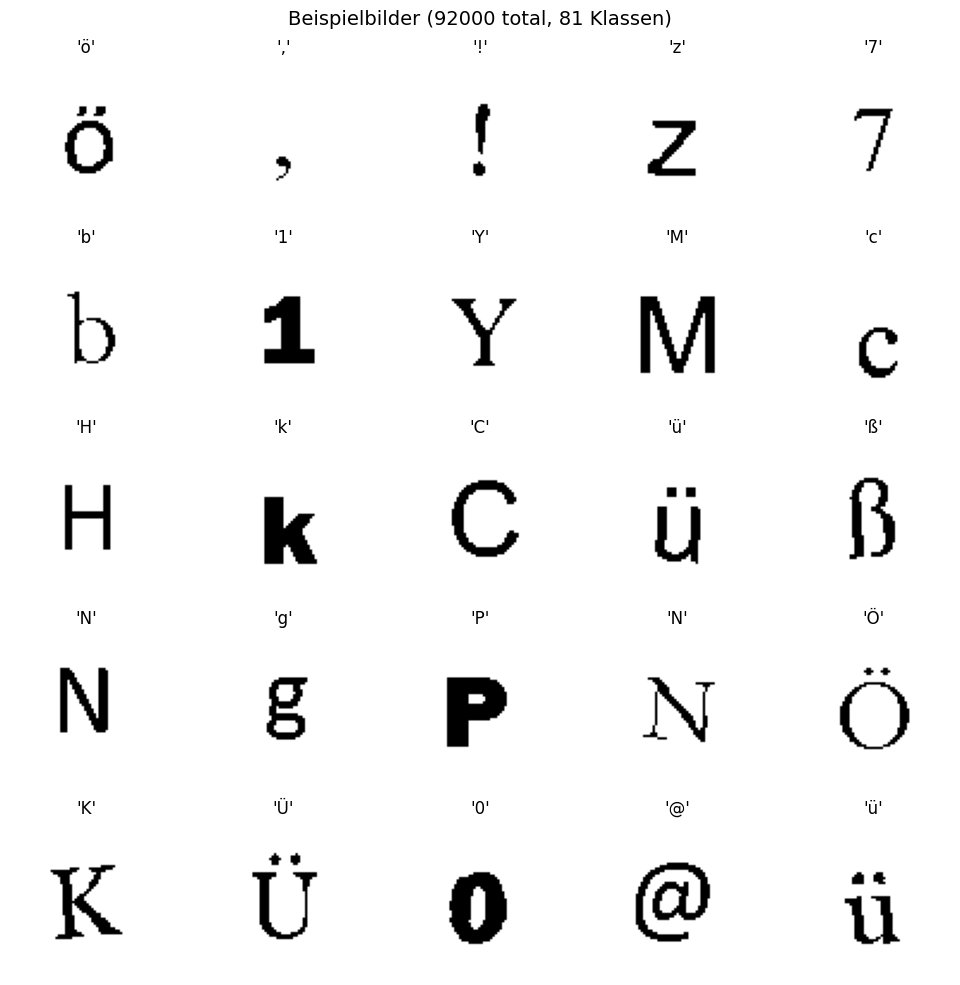

In [68]:
# Datensatz laden
data = np.load(OUTPUT_PATH, allow_pickle=True)
X = data['X']
y = data['y']
chars = data['chars']

# 25 zufällige Bilder auswählen
indices = random.sample(range(len(X)), 25)

# 5x5 Grid erstellen
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    axes[i].imshow(X[idx], cmap='gray')
    axes[i].set_title(f"'{chars[y[idx]]}'", fontsize=12)
    axes[i].axis('off')

plt.suptitle(f"Beispielbilder ({len(X)} total, {len(chars)} Klassen)", fontsize=14)
plt.tight_layout()
plt.show()

In [69]:
DATA_PATH = FILENAME

# Where to save the model checkpoints
CHECKPOINT_DIR = 'checkpoint'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 20
TEST_SPLIT = 0.2  # 20% for testing

In [70]:
# ==========================================
# 2. DATA LOADING & PREPROCESSING
# ==========================================
print(f"\nLoading data from {DATA_PATH}...")

try:
    data = np.load(DATA_PATH, allow_pickle=True)
    X = data['X']
    y = data['y']
    chars = data['chars']
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: File not found at {DATA_PATH}. Please check the path.")
    raise

# Normalize images: Convert 0-255 to 0.0-1.0 (Crucial for Neural Networks)
print("Normalizing images...")
X = X.astype('float32') / 255.0

# Reshape: Add the 'Channel' dimension.
# TensorFlow expects (Batch, Height, Width, Channels) -> (N, 128, 128, 1)
# If your images are grayscale, channels = 1.
if len(X.shape) == 3:
    X = np.expand_dims(X, axis=-1)

print(f"Input Shape: {X.shape}")

# One-Hot Encoding for Labels
num_classes = len(chars)
print(f"Number of classes: {num_classes}")
y = keras.utils.to_categorical(y, num_classes)

# Split into Train and Test sets
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")



Loading data from dataset_aligned.npz...
Data loaded successfully.
Normalizing images...
Input Shape: (92000, 64, 64, 1)
Number of classes: 81
Splitting data...
Training samples: 73600
Testing samples: 18400


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 81)             │        20,817 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,211,793 (8.44 MB)

 Trainable params: 2,211,345 (8.44 MB)

 Non-trainable params: 448 (1.75 KB)


Starting training (64px input)...
Epoch 1/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7028 - loss: 1.2793
Epoch 1: saving model to checkpoint\model_epoch_01_val_acc_0.93.keras

Epoch 1: finished saving model to checkpoint\model_epoch_01_val_acc_0.93.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 168s 145ms/step - accuracy: 0.8829 - loss: 0.4510 - val_accuracy: 0.9282 - val_loss: 0.2614 - learning_rate: 0.0010
Epoch 2/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9799 - loss: 0.0522
Epoch 2: saving model to checkpoint\model_epoch_02_val_acc_0.94.keras

Epoch 2: finished saving model to checkpoint\model_epoch_02_val_acc_0.94.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 180s 156ms/step - accuracy: 0.9813 - loss: 0.0476 - val_accuracy: 0.9440 - val_loss: 0.1824 - learning_rate: 0.0010
Epoch 3/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9805 - loss: 0.0486
Epoch 3: saving model to checkpoint\model_epoch_03_val_acc_0.96.keras

Epoch 3: finished saving model

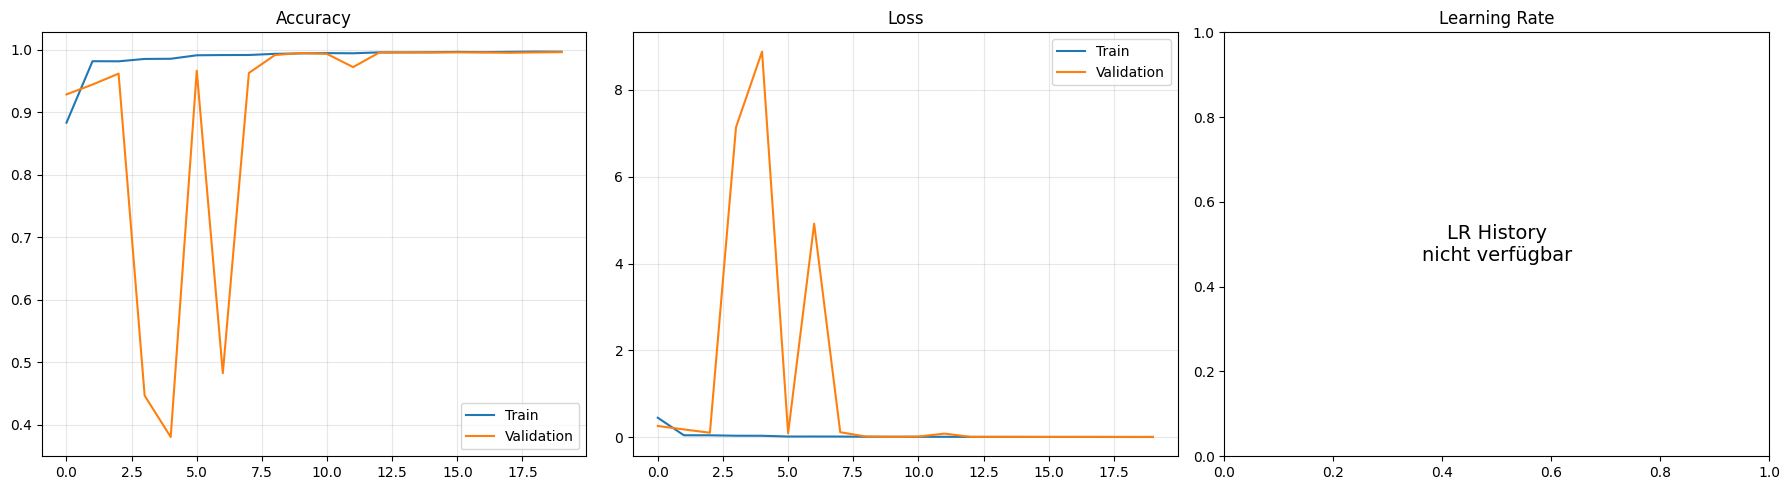

In [71]:
# ==========================================
# MODEL DEFINITION (64x64 INPUT)
# ==========================================
model = models.Sequential([
    # Block 1: 64x64 → 32x32
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(64, 64, 1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2: 32x32 → 16x16
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 16x16 → 8x8
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Klassifikationskopf
    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==========================================
# CALLBACKS
# ==========================================
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "model_epoch_{epoch:02d}_val_acc_{val_accuracy:.2f}.keras"
)

my_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_weights_only=False,
        monitor='val_accuracy',
        mode='max',
        save_best_only=False,
        verbose=1
    ),

    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,              # erhöht: gibt dem LR-Scheduler Zeit zu wirken
        restore_best_weights=True
    ),

    # NEU: Lernrate halbieren wenn val_loss 2 Epochen stagniert
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# ==========================================
# TRAINING
# ==========================================
print("\nStarting training (64px input)...")

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=my_callbacks
)

# ==========================================
# EVALUATION & SAVING
# ==========================================
print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

final_save_path = os.path.join(CHECKPOINT_DIR, 'final_german_ocr_model_64px.keras')
model.save(final_save_path)
print(f"Final model saved to: {final_save_path}")

# Plot History
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# NEU: Learning Rate Plot
if 'lr' in history.history:
    axes[2].plot(history.history['lr'])
    axes[2].set_title('Learning Rate')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'LR History\nnicht verfügbar',
                 ha='center', va='center', fontsize=14)
    axes[2].set_title('Learning Rate')

plt.tight_layout()
plt.show()